# Supplementary Figures S2–S3: AGIST and finite-range attraction

Starting with the distributed observations and trained models, calculate the
velocity agreement in S2 and the five-seed attraction evaluation in S3.
Then convert those calculations to the plotted arrays and draw both pages.

Run these cells in order with the CytoBridge code folder available.
The downloads total about 80 MB.
Set `CYTOBRIDGE_DEVICE` to your GPU (or `cpu`, which is much slower).
Choose a new `CYTOBRIDGE_RUN_LABEL` when repeating the calculations.

S2 uses the recorded generator velocity as its known reference, and evaluates
the fitted velocity, score-gradient and grouped interaction on the same rows.
The groups are broad unsupervised state partitions, not annotated cell types.
S3 holds the model fixed and changes the five inference seeds.

To generate the S3 observations or train its radial model from scratch,
follow [S3 data generation and training](../../reference/figure_sources/agist.md).
That guide shows how to select the new evaluation in this notebook.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

import CytoBridge as cb
from IPython.display import Image, display

project = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")).resolve()
device = os.environ.get("CYTOBRIDGE_DEVICE", "cuda")
run_name = os.environ.get("CYTOBRIDGE_RUN_LABEL", "reader_run")
repo = Path(cb.__file__).resolve().parents[1]

def run(module, *arguments):
    subprocess.run([sys.executable, "-m", module, *map(str, arguments)],
                   cwd=repo, check=True)

agist_root = Path(os.environ.get("CYTOBRIDGE_AGIST_DATA", project / "data/agist"))
simulation_root = Path(os.environ.get("CYTOBRIDGE_SIMULATION_DATA", project / "data/simulation"))
if not (agist_root / "model/model_final").is_file():
    cb.datasets.download("agist", destination=project)
if not (simulation_root / "training/model/Score_Refine/best_model.pth").is_file():
    cb.datasets.download("simulation", destination=project)
output = project / "outputs" / ("agist_" + run_name)
output.mkdir(parents=True, exist_ok=False)

## S2. Define state partitions from the 50 gene-state coordinates

Fit the original MiniBatchKMeans candidates (3–8 groups), select by silhouette
score, and number the selected groups by their mean first principal component.
This writes both assignments and selection diagnostics from the observations.

In [2]:
clusters = output / "state_partitions"
run("scripts.prepare_agist_state_clusters",
    "--input", agist_root / "mouse_brain_simulation.csv",
    "--output-dir", clusters)

Selected k=3
outputs/agist_final_logged_inputs_20260908/state_partitions/agist_state_cluster_assignments.csv


## S2. Evaluate the fitted model and compare its full velocity with the generator

The full velocity is intrinsic drift + interaction + score gradient. Cosines
are calculated separately in the two spatial coordinates and all 50 gene-state
coordinates; the displayed gene score is not a two-dimensional projection.

In [3]:
import numpy as np
from reproduction.agist.inputs import evaluate_velocity, velocity_inputs

observed, predicted = evaluate_velocity(
    agist_root / "mouse_brain_simulation.csv", agist_root / "config.yaml",
    agist_root / "model", agist_root / "edge_classifier/mouse.pt",
    device=device, seed=42)
np.savez_compressed(output / "s2_model_velocity.npz", **predicted)
velocity = velocity_inputs(
    observed, predicted, agist_root / "figure_fields/figure_fields.npz",
    clusters / "agist_state_cluster_assignments.csv",
    clusters / "cluster_selection_diagnostics.csv")
velocity["source_velocity_overall"]

,velocity_space,n,mean,std,se,ci95_low,ci95_high,median,q25,q75
0,gene,31816,0.943353,0.071546,0.000401,0.942567,0.944139,0.964600,0.926414,0.990786
1,physical,31816,0.921971,0.266606,0.001495,0.919042,0.924901,0.997422,0.981553,0.999593


## S3. Simulate and evaluate the fitted attraction model

Use the original 400-particle reference, five seeds, and Score_Refine checkpoint.
The paper's S3 evaluation does **not** include the score term. It compares
interaction-on and interaction-off trajectories from the same checkpoint,
evaluates growth with learned masses, and probes the radial interaction curve.

For exactly the recorded stochastic trajectories, set
`CYTOBRIDGE_ATTRACTION_EVALUATION` to an existing evaluation directory.
That explicit choice reuses model results; otherwise this cell performs a new
evaluation. Small stochastic/numerical differences from the paper are possible.

In [4]:
evaluation_override = os.environ.get("CYTOBRIDGE_ATTRACTION_EVALUATION")
simulation_data = Path(os.environ.get("CYTOBRIDGE_ATTRACTION_DATA", simulation_root / "data"))
simulation_model = Path(os.environ.get("CYTOBRIDGE_ATTRACTION_MODEL", simulation_root / "training/model"))
if evaluation_override:
    evaluation = Path(evaluation_override)
else:
    evaluation = output / "attraction_evaluation"
    command = [sys.executable, "-m", "scripts.run_spatial_synthetic_benchmark", "evaluate",
        "--data-dir", simulation_data,
        "--model-dir", simulation_model,
        "--stage", "Score_Refine", "--evaluation-dir", evaluation,
        "--seeds", "1,4,8,32,256", "--no-score", "--no-plots", "--device", device]
    with (output / "attraction_evaluation.log").open("w") as log:
        subprocess.run(list(map(str, command)), cwd=repo, check=True,
                       stdout=log, stderr=subprocess.STDOUT)

## Convert the calculated results to the displayed arrays

S3a reads the measured snapshots. S3b selects the original 60 particle
identities from the dense seed-1 rollout (selection seed 11).
The growth, radial-force and interaction-ablation tables come from the
evaluation directory above.

In [5]:
from reproduction.agist.inputs import attraction_inputs, collect_agist_inputs
from CytoBridge.results import calculate_agist_figure_panels, write_agist_figure_tables

attraction = attraction_inputs(simulation_data / "attractive_observed.h5ad", evaluation)
data = collect_agist_inputs(output / "plot_inputs", velocity=velocity, attraction=attraction)
panels = calculate_agist_figure_panels(data)
tables = write_agist_figure_tables(panels, output / "figures")
tables

{'s2_by_time': PosixPath('outputs/agist_final_logged_inputs_20260908/figures/s2_velocity_by_time.csv'),
 's2_by_cluster': PosixPath('outputs/agist_final_logged_inputs_20260908/figures/s2_velocity_by_state_cluster.csv'),
 's2_overall': PosixPath('outputs/agist_final_logged_inputs_20260908/figures/s2_velocity_overall.csv'),
 's2_time_cluster': PosixPath('outputs/agist_final_logged_inputs_20260908/figures/s2_velocity_by_time_and_state_cluster.csv'),
 's3_growth': PosixPath('outputs/agist_final_logged_inputs_20260908/figures/s3_growth_summary.csv'),
 's3_potential': PosixPath('outputs/agist_final_logged_inputs_20260908/figures/s3_potential_curve.csv'),
 's3_ablation': PosixPath('outputs/agist_final_logged_inputs_20260908/figures/s3_ablation_summary.csv')}

## Draw S2–S3 from those results

S2


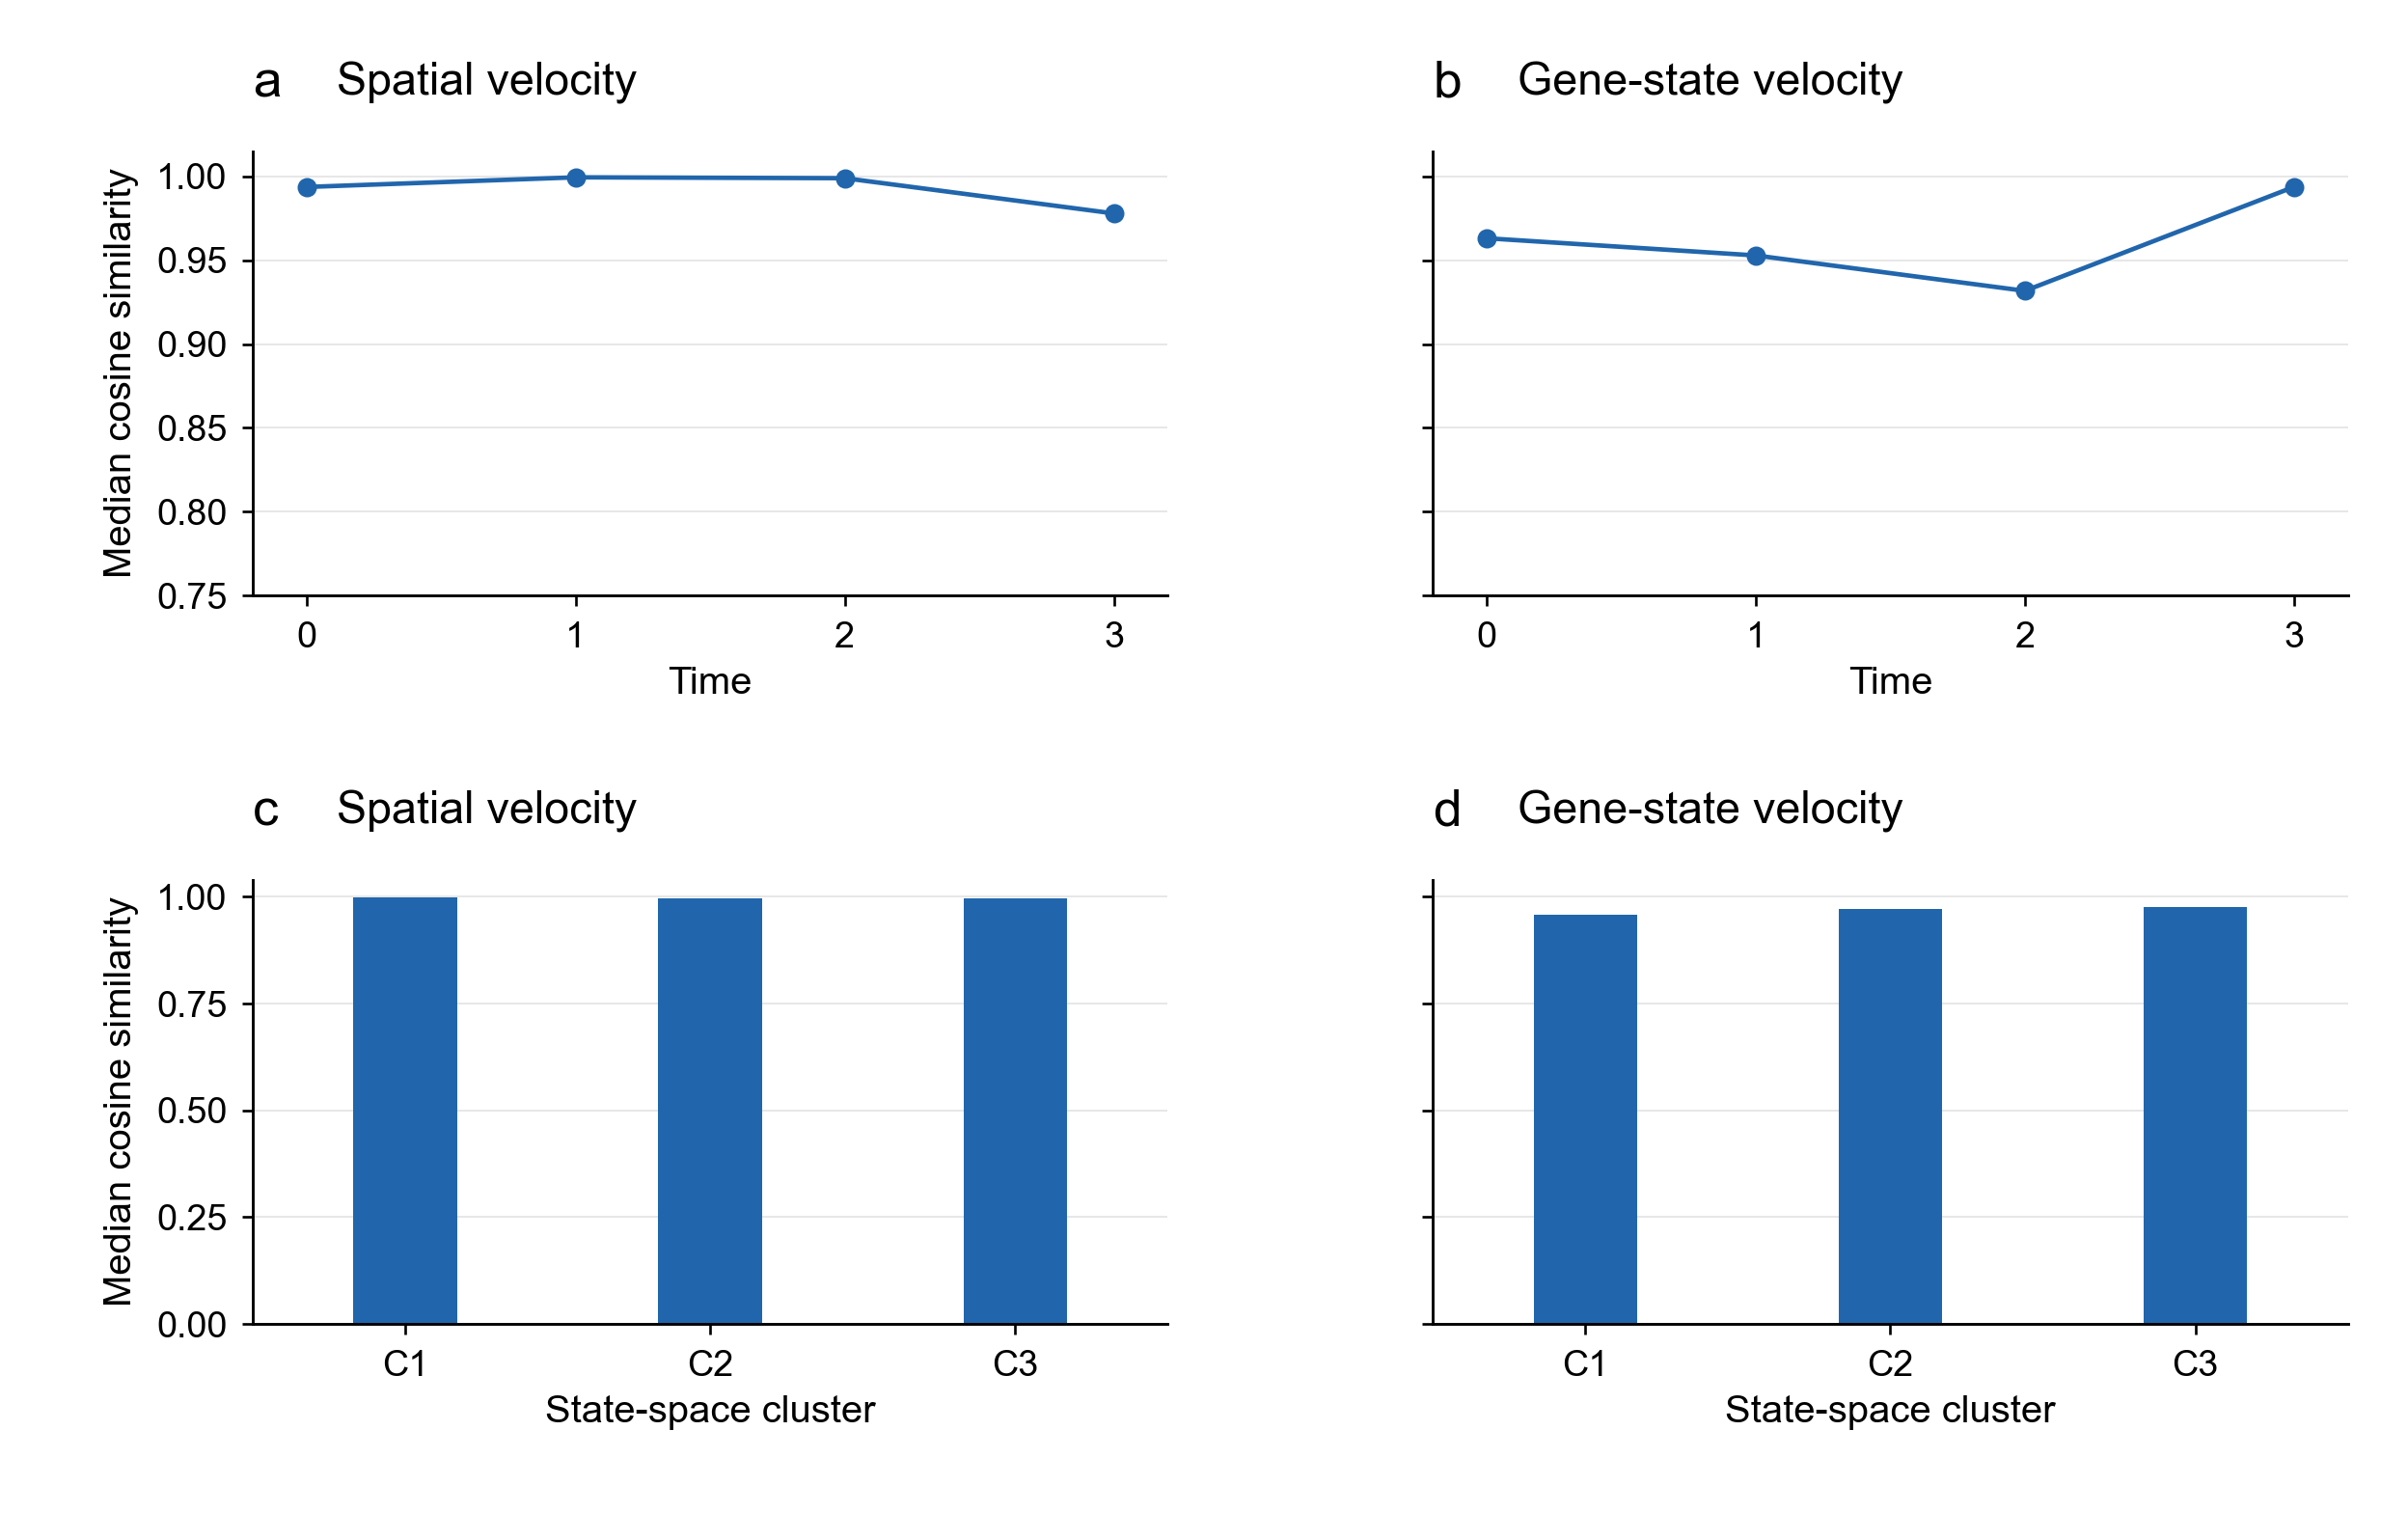

S3


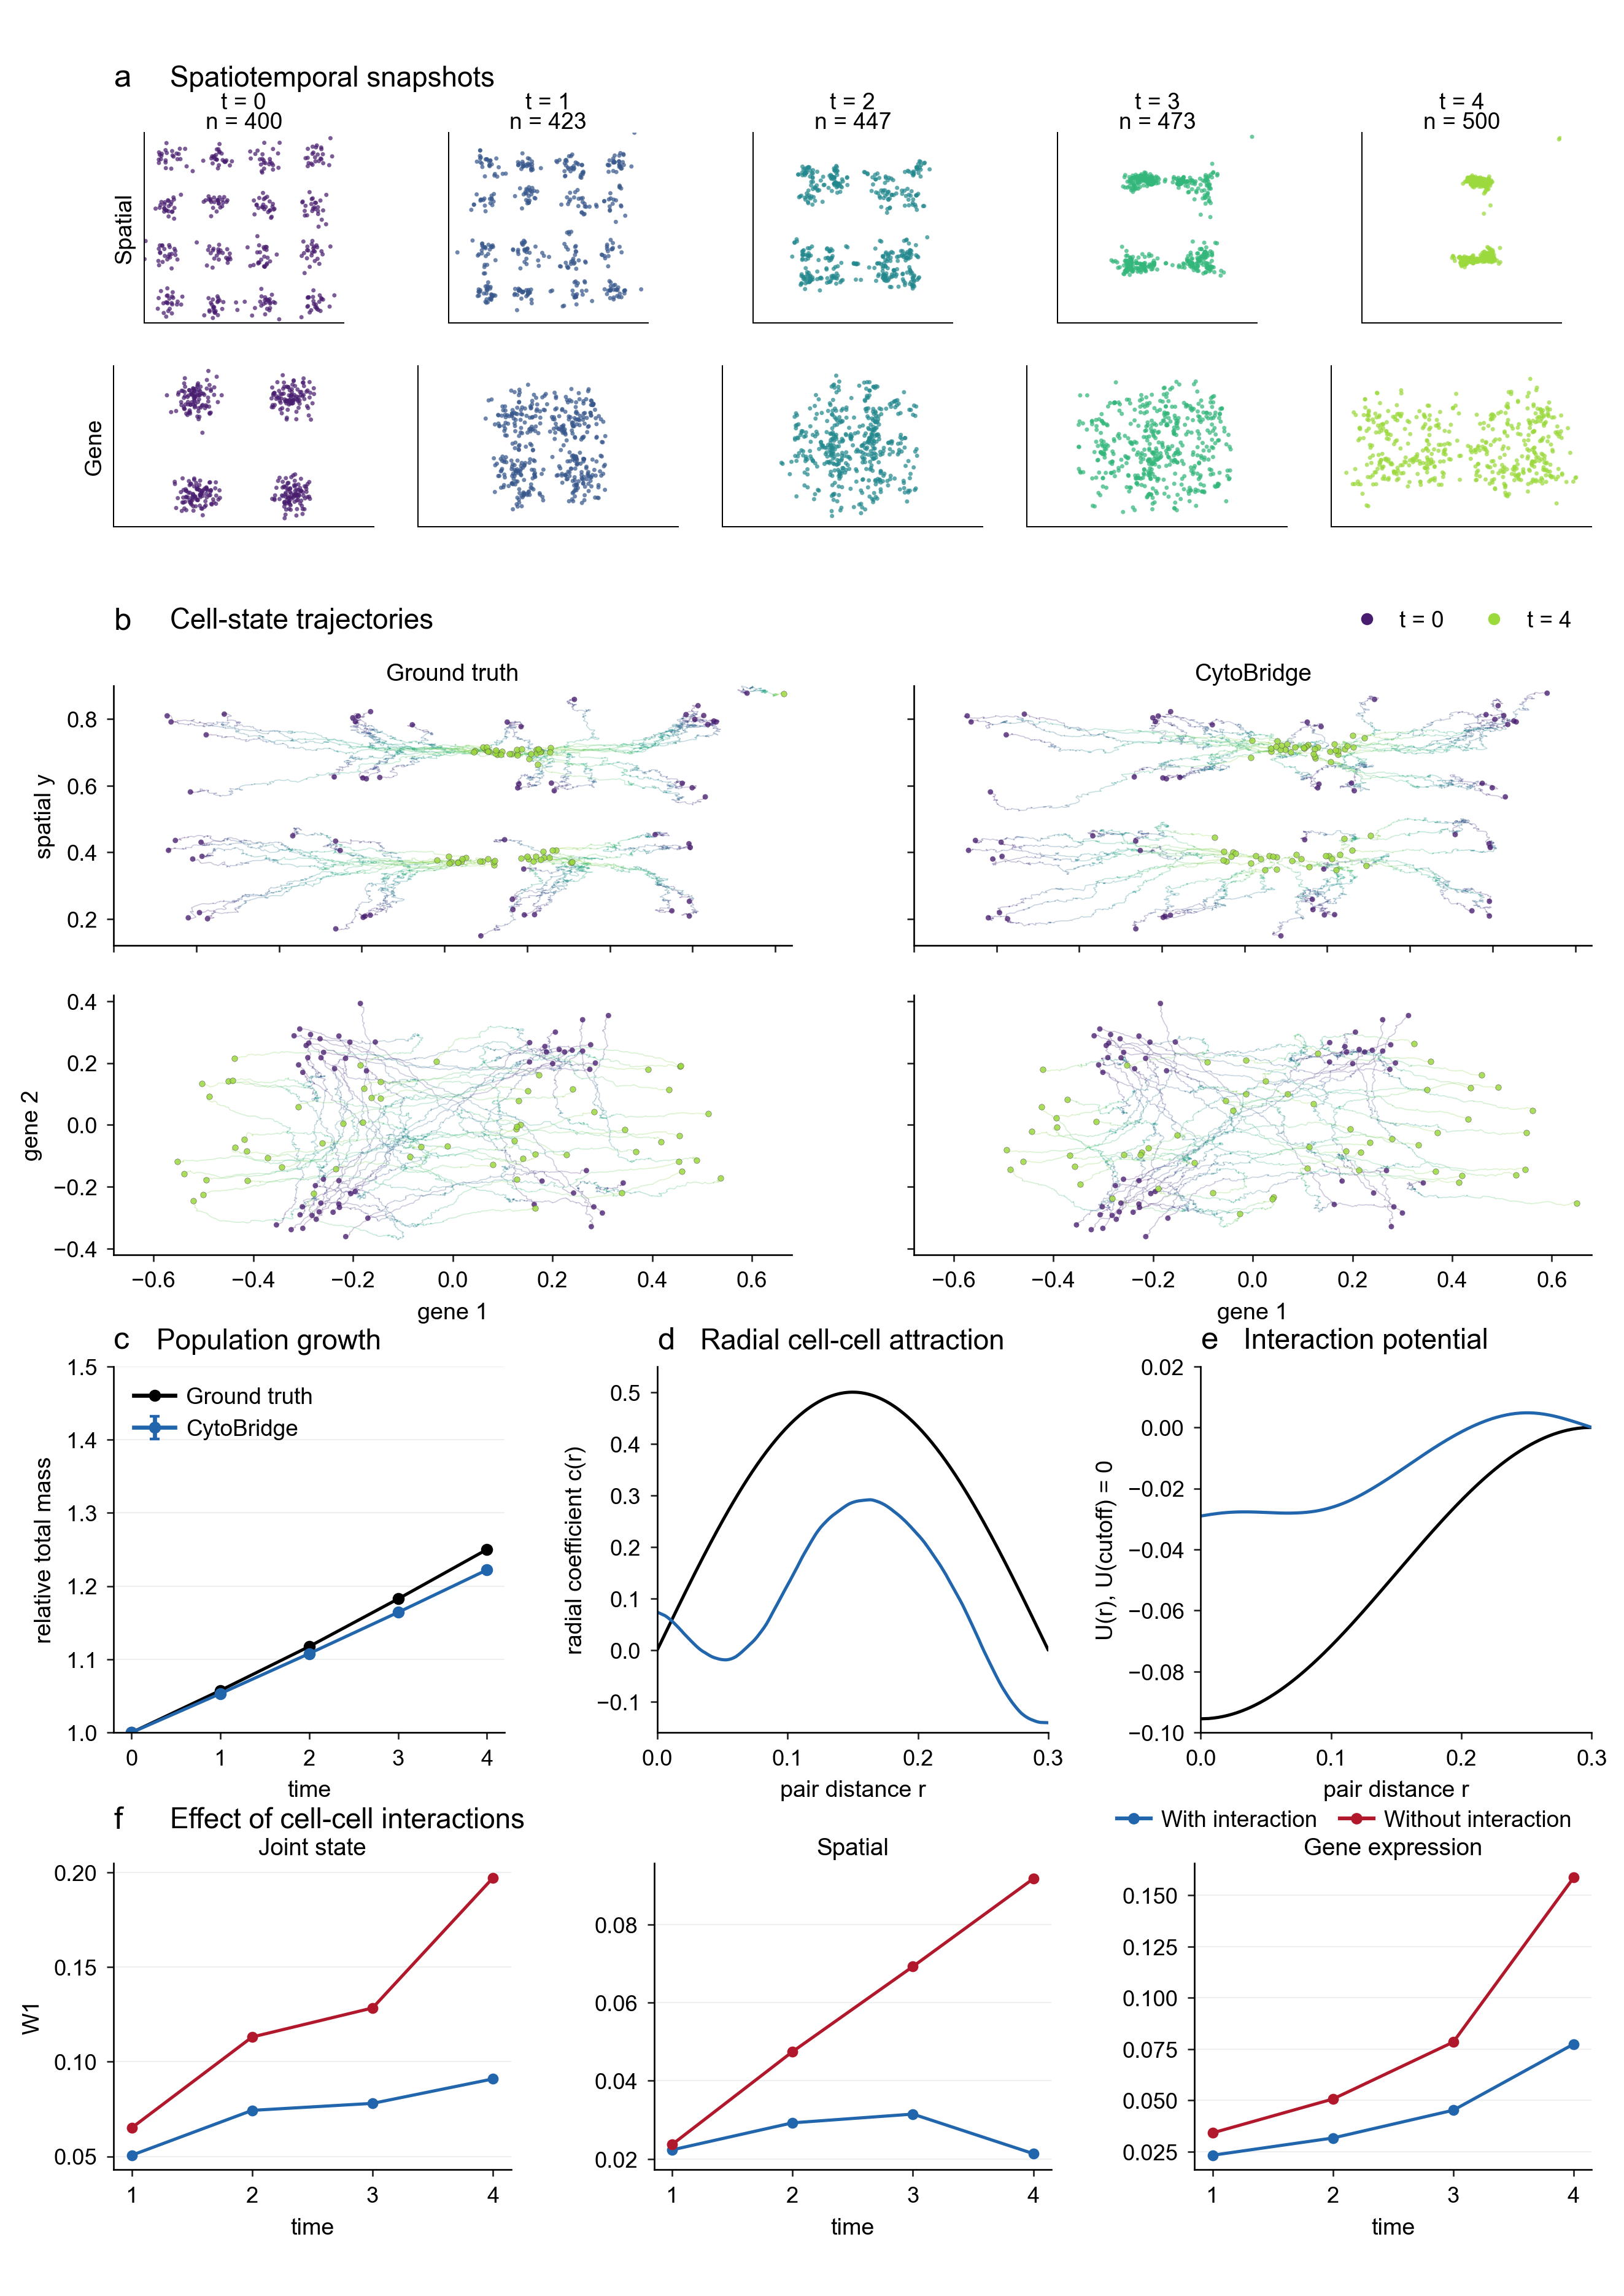

In [6]:
from reproduction.paper_figures import draw_supplementary
figures = draw_supplementary(
    [2, 3], output / "figures", results_dir=data.source_dir,
    data=data, panels=panels)
for name, (_, png) in figures.items():
    print(name.upper())
    display(Image(filename=str(png), width=720))